In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Load Dataset
df = pd.read_csv("../data/cleaned_air_quality.csv")

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(3398, 14)


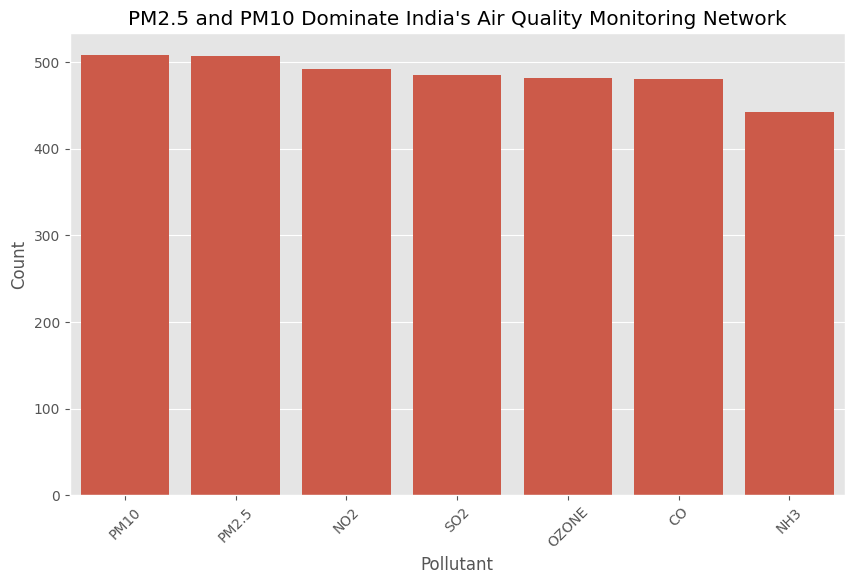

In [2]:
#Chart 1: Most Common Pollutants
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='pollutant_id',
    order=df['pollutant_id'].value_counts().index
)

plt.title(
    "PM2.5 and PM10 Dominate India's Air Quality Monitoring Network"
)

plt.xlabel("Pollutant")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

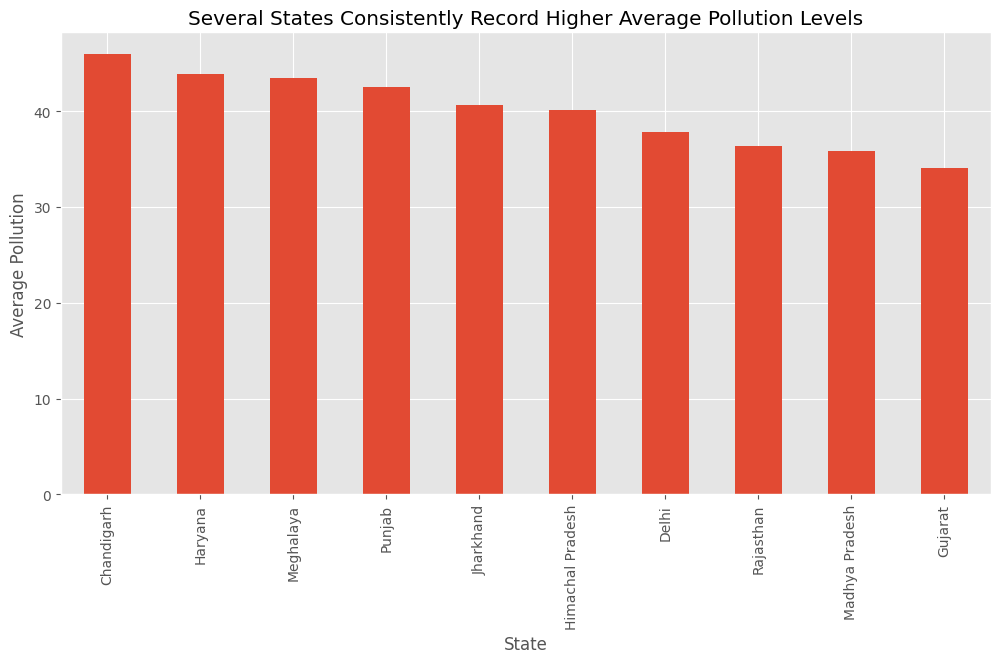

In [3]:
#Chart 2: Top 10 Most Polluted States
top_states = (
    df.groupby('state')['pollutant_avg']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title(
    "Several States Consistently Record Higher Average Pollution Levels"
)

plt.xlabel("State")
plt.ylabel("Average Pollution")

plt.show()

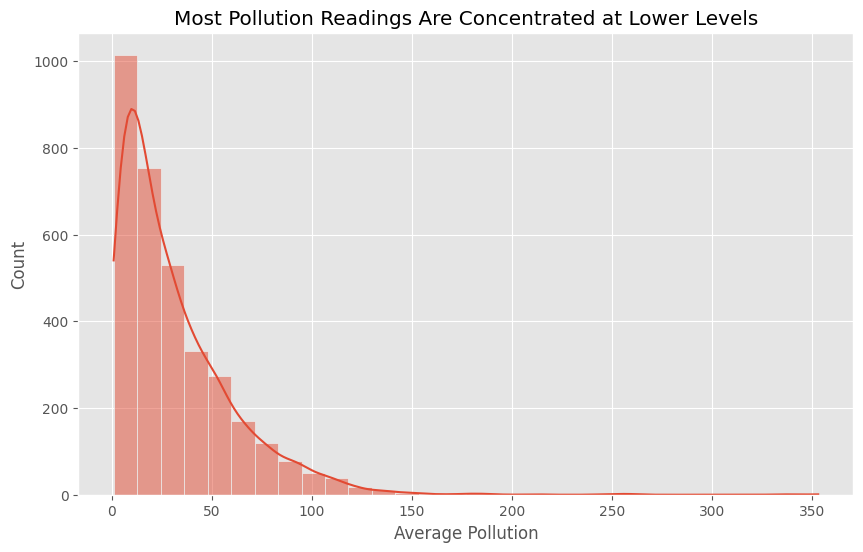

In [4]:
#Chart 3: Pollution Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df['pollutant_avg'],
    bins=30,
    kde=True
)

plt.title(
    "Most Pollution Readings Are Concentrated at Lower Levels"
)

plt.xlabel("Average Pollution")

plt.show()

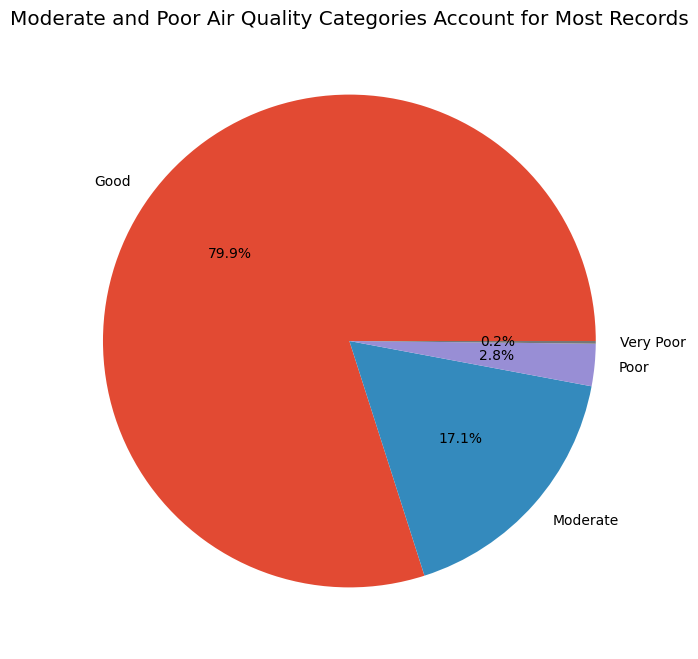

In [5]:
#Chart 4: Pollution Category Share
category_counts = (
    df['pollution_category']
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    "Moderate and Poor Air Quality Categories Account for Most Records"
)

plt.show()

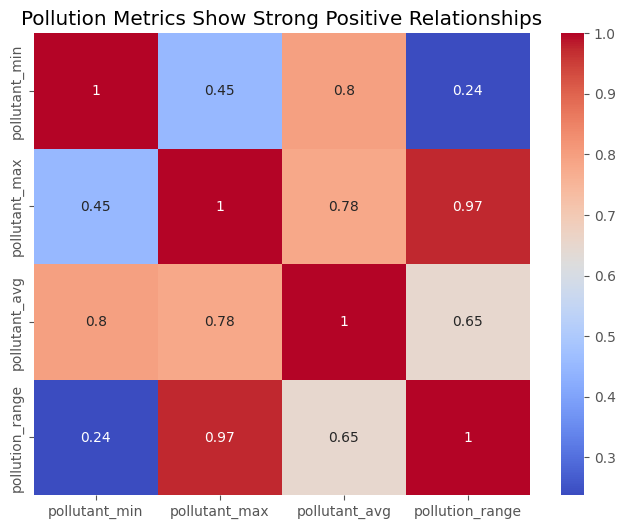

In [6]:
#Chart 5: Correlation Heatmap
corr = df[
    [
        'pollutant_min',
        'pollutant_max',
        'pollutant_avg',
        'pollution_range'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Pollution Metrics Show Strong Positive Relationships"
)

plt.show()

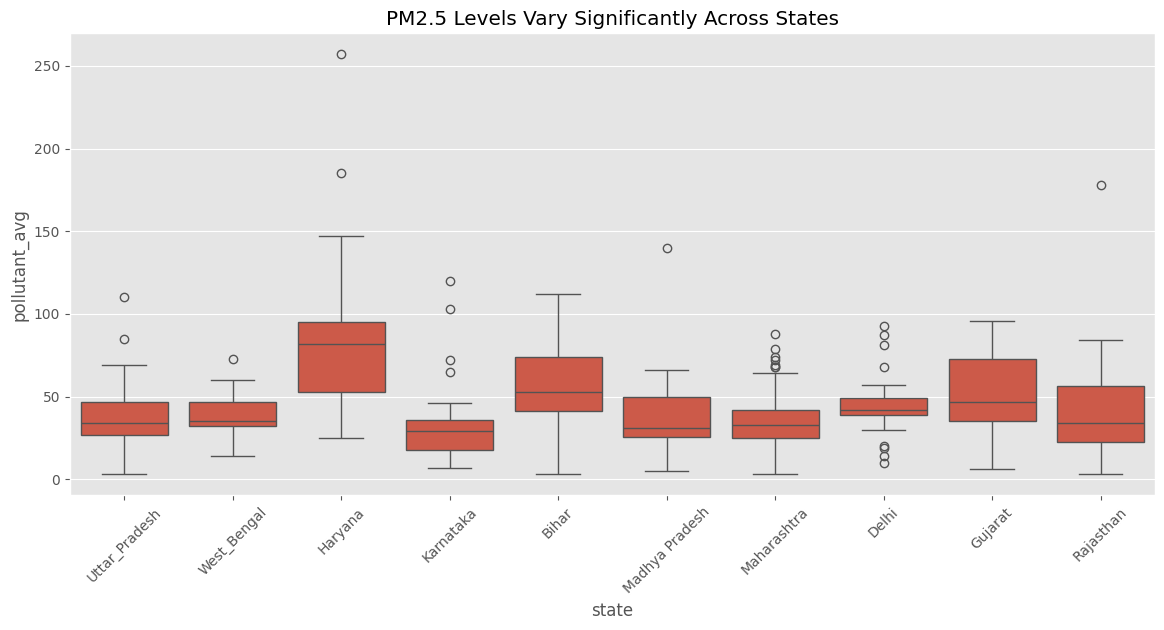

In [7]:
#Chart 6: PM2.5 Variation Across States
pm25 = df[
    df['pollutant_id'] == 'PM2.5'
]

top_pm25_states = (
    pm25['state']
    .value_counts()
    .head(10)
    .index
)

pm25_filtered = pm25[
    pm25['state'].isin(top_pm25_states)
]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=pm25_filtered,
    x='state',
    y='pollutant_avg'
)

plt.xticks(rotation=45)

plt.title(
    "PM2.5 Levels Vary Significantly Across States"
)

plt.show()

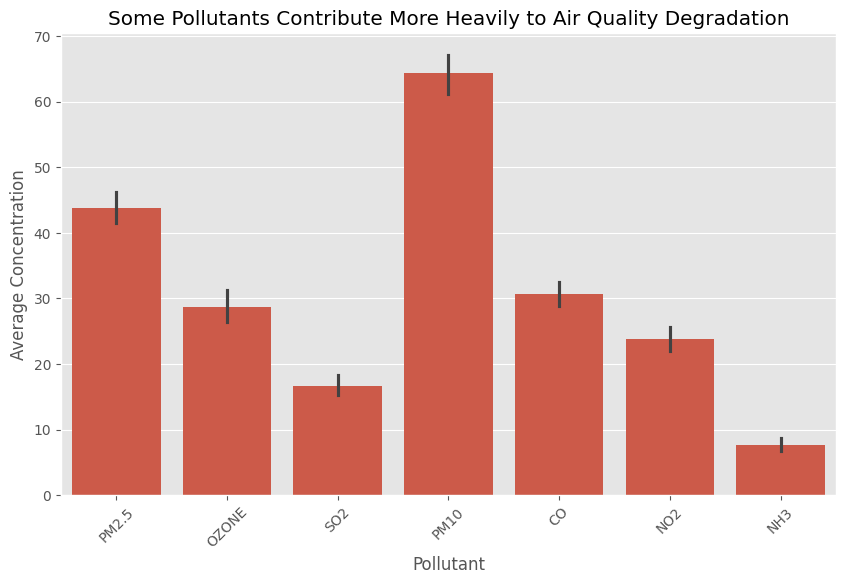

In [8]:
#Chart 7: Pollutant Comparison
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='pollutant_id',
    y='pollutant_avg',
    estimator=np.mean
)

plt.title(
    "Some Pollutants Contribute More Heavily to Air Quality Degradation"
)

plt.xlabel("Pollutant")

plt.ylabel("Average Concentration")

plt.xticks(rotation=45)

plt.show()

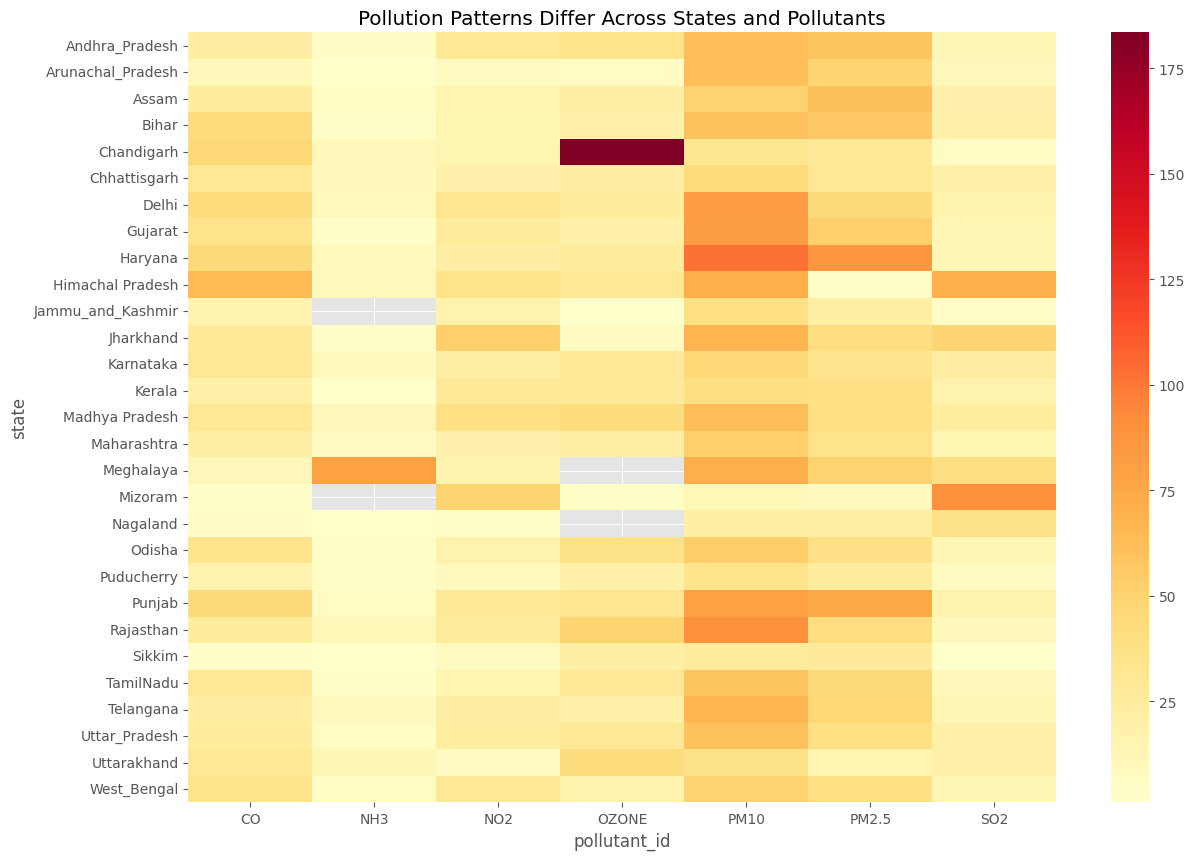

In [9]:
#Chart 8: State vs Pollutant Heatmap
pivot_table = pd.pivot_table(
    df,
    values='pollutant_avg',
    index='state',
    columns='pollutant_id',
    aggfunc='mean'
)

plt.figure(figsize=(14,10))

sns.heatmap(
    pivot_table,
    cmap='YlOrRd'
)

plt.title(
    "Pollution Patterns Differ Across States and Pollutants"
)

plt.show()

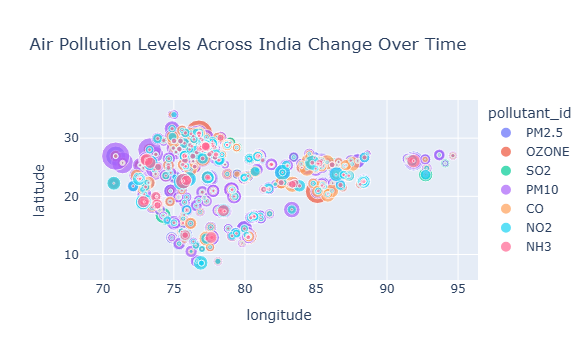

In [11]:
#Animated Plotly Chart
#Convert Date
df['last_update'] = pd.to_datetime(df['last_update'])

df['date'] = df['last_update'].dt.date
#Animated Scatter Plot
animated_chart = px.scatter(
    df,
    x='longitude',
    y='latitude',
    size='pollutant_avg',
    color='pollutant_id',
    animation_frame='date',
    hover_name='city',
    title='Air Pollution Levels Across India Change Over Time'
)

animated_chart.show()

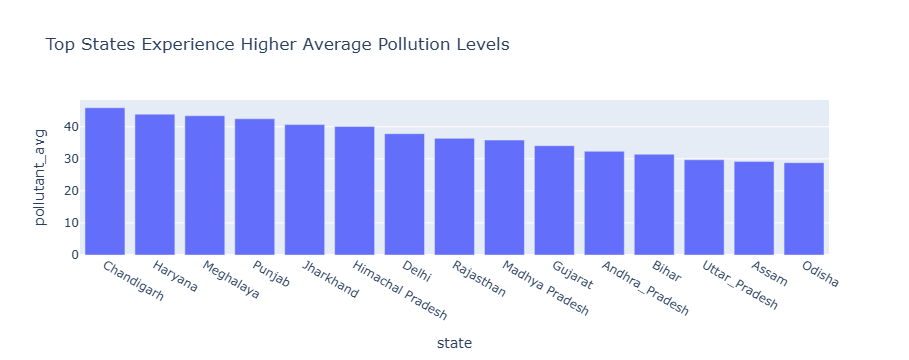

In [12]:
#Interactive Plotly Chart (Bonus)
fig = px.bar(
    df.groupby('state')['pollutant_avg']
    .mean()
    .reset_index()
    .sort_values(
        by='pollutant_avg',
        ascending=False
    )
    .head(15),

    x='state',
    y='pollutant_avg',

    title='Top States Experience Higher Average Pollution Levels'
)

fig.show()